In [ ]:
first_name = "Gregory"
last_name = "Miller"
email = "millegre001@tamu.edu"

I looked into trying 21 separate functions and got stuck at 1.3.
I looked into taking my best working model and separating the outliers so I would have two models to
look through using a GBT but I also was getting around 1.3 log loss.
The only one that was better was what I have below which can get to 1.1424 log loss.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import itertools
from scipy.optimize import linprog
import pickle
import random
import joblib
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import defaultdict
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

2025-04-30 20:30:04.828253: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 20:30:05.066544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746063005.160191     160 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746063005.184697     160 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 20:30:05.381676: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
#The function below will create the G matrix given the parameters n and k where it creates a k size identity matrix 
#and appends a k x n-k -100 to 100 random real numbers

In [ ]:
def G_generator(n, k):
    G = np.identity(k)
    matrix = np.random.uniform(-100, 100, (k, n - k)).astype(np.float32)
    G = np.concatenate((G, matrix), axis=1)
    #print(G)
    return G

In [ ]:
#The function below will make the shape to the max size and flatten it.

In [ ]:
def pad_G(G, max_n = 10, max_k = 6):
    k,n = G.shape
    padded = np.zeros((max_k, max_n), dtype=G.dtype)
    padded[:k,:n] = G
    return padded.flatten()

In [ ]:
#The function below is the tuple generator. 

In [ ]:
def Tuple_generator(n, m):
    tuples = []
    elements = list(range(n))
    for a in elements:
        for b in elements:
            if a != b:
                remaining = [x for x in elements if x not in {a,b}]
                X_sets = itertools.combinations(remaining, m-1) if m - 1 > 0 else [()]
                for X in X_sets:
                    psi_values = itertools.product([-1, 1], repeat = m)
                    for psi in psi_values:
                        tuples.append((a,b,X,psi))
    return tuples

In [ ]:
#The below follows the Linear progression file shown in the project pdf

In [ ]:
def LP_solver(G, a, b, X, psi):
    k, n = G.shape
    bounds = [(None, None)] * k

    X_sorted = sorted(X)
    Y = [x for x in range(n) if x not in {a,b} and x not in X_sorted]
    Y_sorted = sorted(Y)
    x_values = [a] + X_sorted + [b] + Y_sorted
    tau_inv = {val: i for i, val in enumerate(x_values)}
    #negated for minimization as used by the scipy.linprog
    c = [(-psi[0] * G[i, a]) for i in range(k)]
    c = np.array(c)

    A_ub = []
    b_ub = []
    
    for j in X_sorted:
        row = [(psi[tau_inv[j]] * G[i,j] - psi[0] * G[i, a]) for i in range(k)]
        A_ub.append(row)
        b_ub.append(0)

    for j in X_sorted:
        row = [(-psi[tau_inv[j]] * G[i, j]) for i in range(k)]
        A_ub.append(row)
        b_ub.append(-1)

    A_eq = [(G[i,b]) for i in range(k)]
    b_eq = [1]

    for j in Y_sorted:
        row = [(G[i, j]) for i in range(k)]
        A_ub.append(row)
        b_ub.append(1)

    for j in Y_sorted:
        row = [(-G[i,j]) for i in range(k)]
        A_ub.append(row)
        b_ub.append(1)

    
    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)
    A_eq = np.array(A_eq).reshape(1,k)
    b_eq = np.array(b_eq)
    #print("shape of c ", c.shape)
    #print("shape of A_ub ", A_ub.shape)
    #print("shape of b_ub ", b_ub.shape)
    #print("shape of A_eq ", A_eq.shape)
    #print("shape of b_eq ", b_eq.shape)
    
    res = linprog(c, A_ub = A_ub, b_ub = b_ub, A_eq = A_eq, b_eq = b_eq, bounds = bounds, method = 'highs')

    #print(f"Tuple: a={a}, b={b}, X={X}, psi={psi}")
    #print(f"Objective value (raw): {-res.fun if res.success else 'N/A'}")
    #print(f"Solver success: {res.success}, status: {res.status}")
    if res.success:
        return -res.fun
    elif res.status == 3:
        return float("inf")
    else:
        return 0

In [ ]:
#The below function calls all of the above functions and will return the max h_m or inf

In [ ]:
def H_m_computer(G, n, k):
    tuples = Tuple_generator(n,k)
    h_m = max(LP_solver(G, *tpl) for tpl in tuples)
    if h_m == float("inf"):
        return float("inf")
    return h_m


In [ ]:
#The below code below will create 500 samples of the specified n, k, and m value

In [ ]:
def generate_dataset(n,k,m,num_samples_per_config=500):
    config_dataset = []
    num_inf = 0
    max_inf = 0.2 * m * num_samples_per_config
    while len(config_dataset) < num_samples_per_config:
        G = G_generator(n,k)
        h_m = H_m_computer(G,n,m)
        padded_G = pad_G(G)
        sample_data = {'n': n, 'k': k, 'm': m, 'G': padded_G, 'h_m': h_m}
        if h_m == float("inf"):
            if num_inf < max_inf:
                config_dataset.append(sample_data)
                num_inf += 1
            else:
                continue
        else:
            config_dataset.append(sample_data)
    return config_dataset

In [ ]:
#split the below up so I can run them one after another even if the system stops
# I am running Jupyter Notebook in WSL which is limited to only 1.6GB, because of this I originally had it run and append to one large dataset.
#since that took over 20 hours and was only halfway I broke up dataset generation and saving into the 21 different combinations of n,k, and m.
#Then I combined and randomized the data

In [ ]:
dataset = []
dataset = generate_dataset(9,4,2)
with open('dataset2_1.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,4,3)
with open('dataset2_2.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,4,4)
with open('dataset2_3.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,4,5)
with open('dataset2_4.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,5,2)
with open('dataset2_5.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,5,3)
with open('dataset2_6.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,5,4)
with open('dataset2_7.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,6,2)
with open('dataset2_8.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(9,6,3)
with open('dataset2_9.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,4,2)
with open('dataset2_10.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,4,3)
with open('dataset2_11.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,4,4)
with open('dataset2_12.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,4,5)
with open('dataset2_13.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,4,6)
with open('dataset2_14.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,5,2)
with open('dataset2_15.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,5,3)
with open('dataset2_16.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,5,4)
with open('dataset2_17.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,5,5)
with open('dataset2_18.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,6,2)
with open('dataset2_19.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,6,3)
with open('dataset2_20.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
dataset = []
dataset = generate_dataset(10,6,4)
with open('dataset2_21.pkl', 'wb') as f:
    pickle.dump(dataset, f)

In [ ]:
#I stored my Gs that I created from my code and switch them to only be Ps and flatten them

In [ ]:
def transform_G(sample):
    k = int(sample['k'])
    n = int(sample['n'])
    G_mat = np.reshape(sample['G'],(6,10))
    P = G_mat[:,k:]
    padded = np.zeros((6,6), dtype=P.dtype)
    padded[:P.shape[0], :P.shape[1]] = P

    return padded.flatten()

In [ ]:
#From the data that I am using from the dataset that keegan created I need to reformat P to fit my model

In [ ]:
def transform_P(sample):
    k = int(sample['k'])
    n = int(sample['n'])
    G_mat = np.reshape(sample['P'],(k,n-k))
    padded = np.zeros((6,6), dtype=G_mat.dtype)
    padded[:G_mat.shape[0], :G_mat.shape[1]] = G_mat

    return padded.flatten()
    

In [ ]:
#Below loads all of my datasets and splits each before combining them into the train val test sections
#This means that for each n,k,m have the same amount in each train val and test

In [ ]:
files = [
    "dataset1.pkl",
    "dataset2.pkl",
    "dataset3.pkl",
    "dataset4.pkl",
    "dataset5.pkl",
    "dataset6.pkl",
    "dataset7.pkl",
    "dataset8.pkl",
    "dataset9.pkl",
    "dataset10.pkl",
    "dataset11.pkl",
    "dataset12.pkl",
    "dataset13.pkl",
    "dataset14.pkl",
    "dataset15.pkl",
    "dataset16.pkl",
    "dataset17.pkl",
    "dataset18.pkl",
    "dataset19.pkl",
    "dataset20.pkl",
    "dataset21.pkl",
    "dataset2_1.pkl",
    "dataset2_2.pkl",
    "dataset2_3.pkl",
    "dataset2_4.pkl",
    "dataset2_5.pkl",
    "dataset2_6.pkl",
    "dataset2_7.pkl",
    "dataset2_8.pkl",
    "dataset2_9.pkl",
    "dataset2_10.pkl",
    "dataset2_11.pkl",
    "dataset2_12.pkl",
    "dataset2_13.pkl",
    "dataset2_14.pkl",
    "dataset2_15.pkl",
    "dataset2_16.pkl",
    "dataset2_17.pkl",
    "dataset2_18.pkl",
    "dataset2_19.pkl",
    "dataset2_20.pkl",
    "dataset2_21.pkl",
]

train_nkm, val_nkm, test_nkm = [],[],[]
train_G, val_G, test_G = [],[],[]
train_y, val_y, test_y = [],[],[]
for file in files:
    X_params = []
    X_G = []
    y = []
    with open(file, "rb") as f:
        data = joblib.load(f)
    for sample in data:
        X_params.append((sample['n'],sample['k'],sample['m']))
        X_G.append(transform_G(sample))
        y.append(sample['h_m'])
    nkm = np.array(X_params, dtype=np.float32)
    G = np.array(X_G, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    part_train_nkm, temp_nkm, part_train_G, temp_G, part_train_y, temp_y = train_test_split(nkm, G, y, test_size=0.3)
    part_val_nkm, part_test_nkm, part_val_G, part_test_G, part_val_y, part_test_y = train_test_split(temp_nkm, temp_G, temp_y, test_size=0.33)
    train_nkm.append(part_train_nkm)
    train_G.append(part_train_G)
    train_y.append(part_train_y)
    val_nkm.append(part_val_nkm)
    val_G.append(part_val_G)
    val_y.append(part_val_y)
    test_nkm.append(part_test_nkm)
    test_G.append(part_test_G)
    test_y.append(part_test_y)


#for sample in data_records:
#    X_params.append((sample['n'],sample['k'],sample['m']))
#    X_G.append(transform_P(sample))
#    y.append(sample['result'])

In [ ]:
#loads keegans set and puts it into a dictionary

In [ ]:
other_data = joblib.load("results_dataframe.pkl")
print(len(other_data))
data_records = other_data.to_dict('records')
print(len(data_records))

In [ ]:
#splits the data by the nkm

In [ ]:
data_by_config = defaultdict(list)
for sample in data_records:
    key = (sample['n'], sample['k'], sample['m'])
    data_by_config[key].append(sample)

In [ ]:
#stores the split data into a bunch of pkl files bc I was crashing whenever I loaded too much at once

In [ ]:
for key, samples in data_by_config.items():
    n, k, m = key
    filename = f"dataset_n{n}_k{k}_m{m}.pkl"
    joblib.dump(samples, filename)

In [ ]:
#below loads the datasets from keegan and takes 10000 values of each and splits these 10k into train val and test
#again evenly split

In [ ]:
files = [
    "dataset_n9_k4_m2.pkl",
    "dataset_n9_k4_m3.pkl",
    "dataset_n9_k4_m4.pkl",
    "dataset_n9_k4_m5.pkl",
    "dataset_n9_k5_m2.pkl",
    "dataset_n9_k5_m3.pkl",
    "dataset_n9_k5_m4.pkl",
    "dataset_n9_k6_m2.pkl",
    "dataset_n9_k6_m3.pkl",
    "dataset_n10_k4_m2.pkl",
    "dataset_n10_k4_m3.pkl",
    "dataset_n10_k4_m4.pkl",
    "dataset_n10_k4_m5.pkl",
    "dataset_n10_k4_m6.pkl",
    "dataset_n10_k5_m2.pkl",
    "dataset_n10_k5_m3.pkl",
    "dataset_n10_k5_m4.pkl",
    "dataset_n10_k5_m5.pkl",
    "dataset_n10_k6_m2.pkl",
    "dataset_n10_k6_m3.pkl",
    "dataset_n10_k6_m4.pkl"
]

for file in files:
    X_params = []
    X_G = []
    y = []
    with open(file, "rb") as f:
        data = joblib.load(f)
    for sample in data[:10000]:
        X_params.append((sample['n'],sample['k'],sample['m']))
        X_G.append(transform_P(sample))
        y.append(sample['result'])
    nkm = np.array(X_params, dtype=np.float32)
    G = np.array(X_G, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    part_train_nkm, temp_nkm, part_train_G, temp_G, part_train_y, temp_y = train_test_split(nkm, G, y, test_size=0.3)
    part_val_nkm, part_test_nkm, part_val_G, part_test_G, part_val_y, part_test_y = train_test_split(temp_nkm, temp_G, temp_y, test_size=0.33)
    train_nkm.append(part_train_nkm)
    train_G.append(part_train_G)
    train_y.append(part_train_y)
    val_nkm.append(part_val_nkm)
    val_G.append(part_val_G)
    val_y.append(part_val_y)
    test_nkm.append(part_test_nkm)
    test_G.append(part_test_G)
    test_y.append(part_test_y)

train_nkm = np.vstack(train_nkm)
train_G = np.vstack(train_G)
train_y = np.concatenate(train_y)
val_nkm = np.vstack(val_nkm)
val_G = np.vstack(val_G)
val_y = np.concatenate(val_y)
test_nkm = np.vstack(test_nkm)
test_G = np.vstack(test_G)
test_y = np.concatenate(test_y)

print(train_nkm.shape,val_nkm.shape,test_nkm.shape)

In [ ]:
#loading the saved 221k data points that I sorted
# I have taken the nkm and P and made them into some variations of those as well as G

In [5]:
train_nkm = joblib.load('train_nkm2.pkl')
train_G   = joblib.load('train_G2.pkl')
train_y   = joblib.load('train_y2.pkl')

val_nkm   = joblib.load('val_nkm2.pkl')
val_G     = joblib.load('val_G2.pkl')
val_y     = joblib.load('val_y2.pkl')

test_nkm  = joblib.load('test_nkm2.pkl')
test_G    = joblib.load('test_G2.pkl')
test_y    = joblib.load('test_y2.pkl')
train_P = train_G
train_G = []
for i in range(len(train_P)):
    train_G.append(train_P[i].reshape(6,10))
val_P = val_G
val_G = []
for i in range(len(val_P)):
    val_G.append(val_P[i].reshape(6,10))
test_P = test_G
test_G = []
for i in range(len(test_P)):
    test_G.append(test_P[i].reshape(6,10))
train_G = np.array(train_G, dtype=np.float32)
val_G = np.array(val_G, dtype=np.float32)
test_G = np.array(test_G, dtype=np.float32)
print(train_nkm.shape,val_nkm.shape,test_nkm.shape)
print(train_G.shape,val_G.shape,test_G.shape)
print(train_y.shape,val_y.shape,test_y.shape)

(2954700, 7) (848400, 7) (417900, 7)
(2954700, 6, 10) (848400, 6, 10) (417900, 6, 10)
(2954700,) (848400,) (417900,)


In [6]:
#create the inputs for the DNNs
# create an initial preprocessing DNN that does processing on G
# tried to put CNN here and it made my model worse

In [51]:
inputs_nkm = keras.Input(shape=(7,))
inputs_G = keras.Input(shape=(6,10,))
x = layers.Dense(448)(inputs_G)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.1)(x)
dnn_in = layers.Dense(128, activation='relu')(x)
#reshaped_G = layers.Lambda(lambda x: tf.reshape(x, (-1,6,6)))(inputs_G)

In [52]:
#A function to create an expert model from what I tested when I had l1 l2 regularizaiton on all three it did not work as well
#if I had the dropout at .5 for all three it did worse and if I had it less than the current values I saw overfitting
#when I messed with the number of nodes they would either reduce or make things worse
#the input is the input_G and the output 
# I noticed that I had severe underfitting after adding what I put above so I removed regularizers and minimized the dropout
#this allowed for my training error to catch up to my val error

#I tried to create and test hyperparameters of the values below but I could never get the values that 
#seemed to work there work for my actual model so I decided to scrap the couple of days I put into that

# I removed all regularization as after 1000 runs my validation was not that far behind training
# because I used such a large model with such a large amount of nodes it took a while for training to catchup to validation
# however, if I had the last dropout in my expert builder training would never pass validation

In [53]:
def expert_builder(x):
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(96)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # x = layers.Dropout(0.1)(x)
    out = layers.Dense(1)(x)
    return out

In [54]:
#I tested with a few different numebr of experts and noticed that the more there were the better
# The layers below the experts_tensor will take the inputs for nkm and then get a softmax that selects the different experts that are good
# These softmax values will be dot producted with the experts to return the true output.
# I also have some callbacks to speedup the training that monitor val_mae to plateau the learning rate and stop the training early

In [55]:
experts = []
for i in range(5):
    new_expert = expert_builder(dnn_in)
    experts.append(new_expert)

experts_tensor = layers.Concatenate(axis=1, name='experts_added')(experts)
flat_G = layers.Flatten()(inputs_G)
x_nkm = layers.Concatenate()([inputs_nkm, flat_G])
x_nkm = layers.Dense(512)(x_nkm)
x_nkm = layers.BatchNormalization()(x_nkm)
x_nkm = layers.Activation("relu")(x_nkm)
x_nkm = layers.Dropout(0.1)(x_nkm)
x_nkm = layers.Dense(30)(x_nkm)
x_nkm = layers.Activation('softmax', name='gate')(x_nkm)

final_out = layers.Dot(axes=1, name='final_output')([x_nkm, experts_tensor])

model1 = keras.Model(inputs = [inputs_nkm, inputs_G], outputs=final_out)
callbacks = [
    keras.callbacks.ModelCheckpoint("mheight_experts.keras", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor='val_mae', patience=300,restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=50, verbose=1)
]

In [56]:
#take the log of the results

In [57]:
train_y_log = np.log2(train_y).reshape(-1, 1)
val_y_log = np.log2(val_y).reshape(-1, 1)
test_y_log = np.log2(test_y).reshape(-1, 1)

In [58]:
#compile the model

In [59]:
def log2_mse(y_true, y_pred):
    sq_diff = tf.square(y_pred - y_true)
    return tf.reduce_mean(sq_diff)
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss=log2_mse, metrics=["mae"])
#model1.summary()

In [60]:
#below runs and trains the model

In [61]:
history = model1.fit([train_nkm, train_G], train_y_log, epochs=1000, batch_size = 1024, validation_data=([val_nkm, val_G], val_y_log), callbacks=callbacks, shuffle=True)

Epoch 1/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 65s 17ms/step - loss: 25.3538 - mae: 3.6063 - val_loss: 2.8825 - val_mae: 1.1771 - learning_rate: 1.0000e-04
Epoch 2/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 2.6446 - mae: 1.1412 - val_loss: 1.6198 - val_mae: 0.8775 - learning_rate: 1.0000e-04
Epoch 3/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 1.8078 - mae: 0.9335 - val_loss: 1.4429 - val_mae: 0.8165 - learning_rate: 1.0000e-04
Epoch 4/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 1.5711 - mae: 0.8570 - val_loss: 1.3777 - val_mae: 0.7860 - learning_rate: 1.0000e-04
Epoch 5/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 1.4689 - mae: 0.8204 - val_loss: 1.3383 - val_mae: 0.7674 - learning_rate: 1.0000e-04
Epoch 6/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 1.4186 - mae: 0.7997 - val_loss: 1.3176 - val_mae: 0.7552 - learning_rate: 1.0000e-04
Epoch 7/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.3751 - mae: 0.7834 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.1091 - mae: 0.6793 - val_loss: 1.1430 - val_mae: 0.6788 - learning_rate: 6.2500e-06
Epoch 781/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.1079 - mae: 0.6796 - val_loss: 1.1436 - val_mae: 0.6793 - learning_rate: 6.2500e-06
Epoch 783/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 1.1110 - mae: 0.6797 - val_loss: 1.1411 - val_mae: 0.6786 - learning_rate: 6.2500e-06
Epoch 784/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.1083 - mae: 0.6796 - val_loss: 1.1417 - val_mae: 0.6781 - learning_rate: 6.2500e-06
Epoch 785/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 1.1094 - mae: 0.6801 - val_loss: 1.1417 - val_mae: 0.6779 - learning_rate: 6.2500e-06
Epoch 786/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.1076 - mae: 0.6790 - val_loss: 1.1399 - val_mae: 0.6780 - learning_rate: 6.2500e-06
Epoch 787/1000
2873/2886 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1119 - mae: 0.6801 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



2886/2886 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 1.1102 - mae: 0.6798 - val_loss: 1.1433 - val_mae: 0.6778 - learning_rate: 6.2500e-06
Epoch 791/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 1.1139 - mae: 0.6806 - val_loss: 1.1461 - val_mae: 0.6791 - learning_rate: 6.2500e-06
Epoch 792/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1060 - mae: 0.6783 
Epoch 792: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 1.1060 - mae: 0.6783 - val_loss: 1.1416 - val_mae: 0.6781 - learning_rate: 6.2500e-06
Epoch 793/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 1.1100 - mae: 0.6797 - val_loss: 1.1432 - val_mae: 0.6786 - learning_rate: 3.1250e-06
Epoch 794/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 1.1087 - mae: 0.6796 - val_loss: 1.1427 - val_mae: 0.6787 - learning_rate: 3.1250e-06
Epoch 795/1000
2886/2886 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 1.1101 - mae: 0.6797 - val

In [ ]:
#Save the model so I do not lose it

In [62]:
model1.save("dnn_mheight_experts221k_P3_best.keras") #add graph for loss and mae

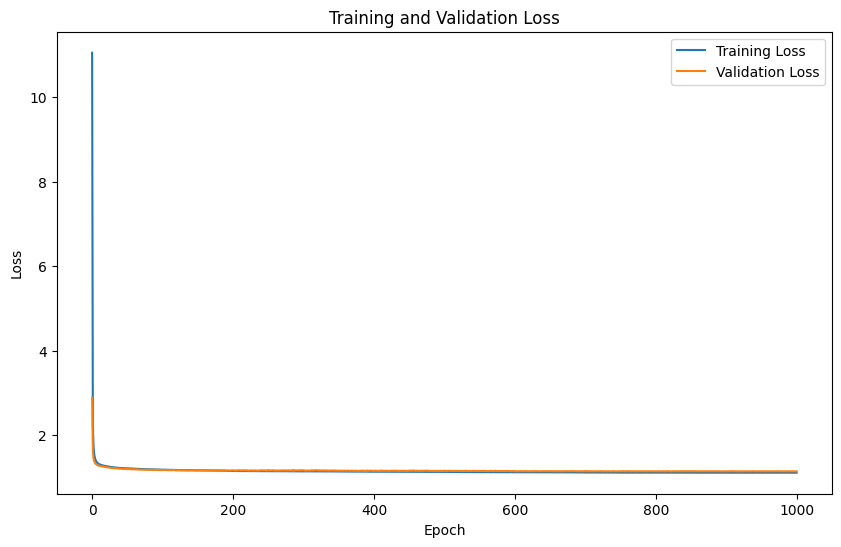

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [64]:
loss, mae = model1.evaluate([test_nkm, test_G], test_y_log)
print("Test Loss:", loss, "Test MAE:", mae)

2025-04-28 09:10:39.802431: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_513', 8 bytes spill stores, 8 bytes spill loads

2025-04-28 09:10:40.586606: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 988 bytes spill stores, 704 bytes spill loads

2025-04-28 09:10:40.765733: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2_0', 168 bytes spill stores, 168 bytes spill loads

2025-04-28 09:10:41.211018: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 96 bytes spill stores, 96 bytes spill loads

2025-04-28 09:10:41.546896: I external/local_xla/xla/stream_exec

13040/13060 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9000 - mae: 0.5856 

2025-04-28 09:11:14.126153: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 988 bytes spill stores, 704 bytes spill loads

2025-04-28 09:11:14.771185: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2_0', 168 bytes spill stores, 168 bytes spill loads

2025-04-28 09:11:14.983092: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 2192 bytes spill stores, 1708 bytes spill loads

2025-04-28 09:11:15.158349: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2025-04-28 09:11:16.219334: I external/local_xla/xla/stream_ex

13060/13060 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.9004 - mae: 0.5857
Test Loss: 1.1424258947372437 Test MAE: 0.6771957874298096


In [65]:
#print a bunch of random points from the test batch of samples

In [66]:
pred_y_log = model1.predict([test_nkm, test_G])
pred_y = 2 ** pred_y_log

random_indices = np.random.choice(len(test_y), size=100, replace=False)
for i in random_indices:
    n, k, m, _, _,_,_ = test_nkm[i]
    actual = np.log(test_y[i])
    predicted = np.log(pred_y[i])
    print(f"Sample {i+1}: n={n}, k={k}, m={m}")
    print(f"   Actual h_m:    {actual}")
    print(f"   Predicted h_m: {predicted}\n")

13060/13060 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step
Sample 121890: n=9.0, k=5.0, m=4.0
   Actual h_m:    9.657183647155762
   Predicted h_m: [10.064818]

Sample 158076: n=9.0, k=6.0, m=2.0
   Actual h_m:    6.370366096496582
   Predicted h_m: [6.297184]

Sample 69174: n=9.0, k=4.0, m=5.0
   Actual h_m:    9.311039924621582
   Predicted h_m: [10.109949]

Sample 45060: n=9.0, k=4.0, m=4.0
   Actual h_m:    6.5541672706604
   Predicted h_m: [6.843965]

Sample 166430: n=9.0, k=6.0, m=3.0
   Actual h_m:    8.030860900878906
   Predicted h_m: [9.480139]

Sample 142254: n=9.0, k=6.0, m=2.0
   Actual h_m:    6.656615734100342
   Predicted h_m: [6.404925]

Sample 141333: n=9.0, k=6.0, m=2.0
   Actual h_m:    6.204379558563232
   Predicted h_m: [6.463542]

Sample 128814: n=9.0, k=5.0, m=4.0
   Actual h_m:    10.825439453125
   Predicted h_m: [10.172858]

Sample 95770: n=9.0, k=5.0, m=2.0
   Actual h_m:    6.317646026611328
   Predicted h_m: [5.78978]

Sample 180551: n=10.0, k=4.0, m=2.0
   Actual h_m:

In [67]:
#Function for running the inputs and outputs for the tests

In [2]:
def recon_G(padded_P, n, k):
    padded_P = padded_P.reshape(6,6)
    P_top = padded_P[:k, :]
    actual_nk = n-k
    P_sub = P_top[:,:actual_nk]

    I = np.eye(k,dtype=padded_P.dtype)

    G = np.concatenate([I, P_sub], axis=1)
    G_pad = np.zeros((6,10), dtype=padded_P.dtype)
    G_pad[:k, :n] = G
    return G_pad

In [3]:
def transform_P(sample):
    k = int(sample['k'])
    n = int(sample['n'])
    G_mat = np.reshape(sample['P'],(k,n-k))
    padded = np.zeros((6,6), dtype=G_mat.dtype)
    padded[:G_mat.shape[0], :G_mat.shape[1]] = G_mat

    return padded.flatten()

In [43]:
def m_height_calculator(inputs):
    final_nkm = []
    final_P = []
    final_result = []
    for i in range(len(inputs)):
        n, k, m, P = inputs[i]
        final_nkm.append((n, k, m, m, m, n-k, (n-k)/m))
        sample = {"n": n, "k": k, "m": m, "P": P}
        #print(inputs[inpt][i])
        #print(inputs[inpt][i].shape)
        P = transform_P(sample)
        G = recon_G(P, sample['n'], sample['k']) 
        final_P.append(G)
        #final_result.append(np.log2(outputs[inpt][i]))

    final_nkm = np.array(final_nkm, dtype=np.float32)
    final_P = np.array(final_P, dtype=np.float32)
    def log2_mse(y_true, y_pred):
        sq_diff = tf.square(y_pred - y_true)
        return tf.reduce_mean(sq_diff)
    model3 = load_model("gerg_P3.keras",custom_objects={"log2_mse": log2_mse})
    pred_y_log = model3.predict([final_nkm, final_P])
    pred_y = 2 ** pred_y_log

    return pred_y#, final_result
        
            

In [44]:
#Add inputs and outputs below and run them

In [36]:
inputs = joblib.load("DS-5-samples_n_k_m_P")
pred1 = m_height_calculator(inputs)
# print(len(pred))
# G = G_generator(9,4)
# sample = {"n": 9, "k": 4, "m": 2, "P": G}
# h = H_m_computer(G, 9, 4)
# print(G)
# P = G[:4,4:]
# print(P)
# print(h)
# G = G_generator(9,4)
# sample = {"n": 9, "k": 4, "m": 2, "P": G}
# h = H_m_computer(G, 9, 4)
# P = G[:4,4:]
# print(P)
# print(h)

116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step


In [37]:
print(pred1)

[[  185.50172]
 [  294.63412]
 [  961.5581 ]
 ...
 [  447.65454]
 [ 1579.4963 ]
 [52154.516  ]]


In [48]:
H1 = pred

In [41]:
pred2 = m_height_calculator(inputs)
H2 = pred2

2025-04-30 14:30:56.747181: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 168 bytes spill stores, 168 bytes spill loads

2025-04-30 14:30:58.382725: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_102', 64 bytes spill stores, 64 bytes spill loads

2025-04-30 14:30:58.611156: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_102', 56 bytes spill stores, 56 bytes spill loads



112/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

2025-04-30 14:31:01.255240: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1622', 16 bytes spill stores, 16 bytes spill loads

2025-04-30 14:31:01.607560: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 168 bytes spill stores, 168 bytes spill loads

2025-04-30 14:31:03.072105: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_102', 64 bytes spill stores, 64 bytes spill loads

2025-04-30 14:31:03.343415: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_102', 56 bytes spill stores, 56 bytes spill loads



116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step


In [42]:
print(pred2)

[[  154.5131 ]
 [  421.54294]
 [ 2051.9204 ]
 ...
 [  355.94995]
 [ 1557.0823 ]
 [60209.07   ]]


In [45]:
pred3 = m_height_calculator(inputs)

2025-04-30 14:31:42.057294: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_505', 8 bytes spill stores, 8 bytes spill loads

2025-04-30 14:31:42.592229: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 988 bytes spill stores, 704 bytes spill loads

2025-04-30 14:31:43.390329: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 4 bytes spill stores, 4 bytes spill loads

2025-04-30 14:31:43.692707: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 96 bytes spill stores, 96 bytes spill loads

2025-04-30 14:31:45.138458: I external/local_xla/xla/stream_executor/c

108/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

2025-04-30 14:31:47.278642: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_505', 12 bytes spill stores, 12 bytes spill loads

2025-04-30 14:31:47.596595: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1_0', 988 bytes spill stores, 704 bytes spill loads

2025-04-30 14:31:48.246547: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2025-04-30 14:31:48.850496: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 88 bytes spill stores, 88 bytes spill loads

2025-04-30 14:31:49.518330: I external/local_xla/xla/stream_executor

116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step


In [47]:
H3 = pred3

In [46]:
print(pred3)

[[  151.03389]
 [  478.14465]
 [ 3983.518  ]
 ...
 [  382.37314]
 [ 1377.9816 ]
 [48648.78   ]]


In [49]:
results = {
    "project_1": H1,
    "project_2": H2,
    "project_3": H3
}


In [50]:
outfile = "CSCE 636-600 Spring 2025 Project Test Results Gregory Miller 631001523.pkl"
with open(outfile, "wb") as f:
    pickle.dump(results, f)

In [4]:
gerg = joblib.load("CSCE 636-600 Spring 2025 Project Test Results Gregory Miller 631001523.pkl")
print(len(gerg))
print(gerg.keys())
for i in gerg.keys():
    print(len(gerg[i]))
    print(gerg[i][0])
    print(type(gerg[i][0][0]))


3
dict_keys(['project_1', 'project_2', 'project_3'])
3704
[185.50172]
<class 'numpy.float32'>
3704
[154.5131]
<class 'numpy.float32'>
3704
[151.03389]
<class 'numpy.float32'>


In [11]:
data = joblib.load("test_hm_values.pkl")
h = []
for i in range(len(data)):
    #print(data[i])
    h.append(data[i][3])
h = np.array(h, dtype=np.float64)
h_log = np.log2(h)
for i in gerg.keys():
    raw = gerg[i]
    preds = np.array([np.asarray(v).ravel()[0] for v in raw])
    pred_log = np.log2(preds)
    mse = np.mean((pred_log - h_log) ** 2)
    print(mse)

1.1502212999359887
1.0250916592062569
0.9582445360263188
